## 📋 Orden de Ejecución del Proyecto

### **Paso 1: Procesar Videos y Generar Dataset**

Este paso procesa todos los videos (Entrega 1 + Entrega 2) y genera los archivos CSV con las features extraídas.

**Script:** `process_all_videos.py`

**Lo que hace:**
- Extrae landmarks de MediaPipe de cada frame
- Sincroniza frames de video con etiquetas de Label Studio
- Calcula 184 features (132 base + 52 derivadas)
- **COMBINA clases** (Walking, Transition)
- Genera 2 archivos:
  - `mediapipe_labels_dataset_combined.csv` (base)
  - `mediapipe_labels_dataset_combined_enriched.csv` (con features derivadas)

**Tiempo estimado:** ~10-15 minutos (43 videos)

**Ejecutar:**

In [1]:
# PASO 1: Procesar todos los videos
!python process_all_videos.py

Inicializando MediaPipe Pose...
PROCESAMIENTO DE TODOS LOS VIDEOS DEL PROYECTO

1. PROCESANDO ENTREGA 1 (Videos APO)
----------------------------------------------------------------------

Procesando Video 1.mp4 (ID 39)...
  Frames OpenCV: 409, Label Studio max: 330, FPS: 29.93
  Ratio: 0.8068, Source: Entrega1

Procesando Video 2.mp4 (ID 40)...
  Frames OpenCV: 479, Label Studio max: 386, FPS: 29.94
  Ratio: 0.8058, Source: Entrega1

Procesando Video 3.mp4 (ID 41)...
  Frames OpenCV: 343, Label Studio max: 262, FPS: 29.91
  Ratio: 0.7638, Source: Entrega1

Procesando Video 4.mp4 (ID 42)...
  Frames OpenCV: 467, Label Studio max: 375, FPS: 29.94
  Ratio: 0.8030, Source: Entrega1

Procesando Video 5.mp4 (ID 43)...
  Frames OpenCV: 468, Label Studio max: 352, FPS: 29.94
  Ratio: 0.7521, Source: Entrega1

Procesando Video 6.mp4 (ID 44)...
  Frames OpenCV: 382, Label Studio max: 308, FPS: 29.93
  Ratio: 0.8063, Source: Entrega1

Procesando Video 7.mp4 (ID 45)...
  Frames OpenCV: 488, Label

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.

  Video 1.mp4: 100%|██████████| 409/409 [00:12<00:00, 31.74it/s]

  Video 2.mp4: 100%|██████████| 479/479 [00:13<00:00, 34.48it/s]

  Video 3.mp4: 100%|██████████| 343/343 [00:09<00:00, 35.66it/s]

  Video 4.mp4: 100%|██████████| 467/467 [00:12<00:00, 38.04it/s]

  Video 5.mp4: 100%|██████████| 468/468 [00:12<00:00, 37.81it/s]

  Video 6.mp4: 100%|██████████| 382/382 [00:10<00:00, 37.41it/s]

  Video 7.mp4: 100%|██████████| 488/488 [00:13<00:00, 35.15it/s]

  Video 8.mp4: 100%|██████████| 368/368 [00:10<00:00, 34.14it/s]

  Video 9.mp4: 100%|██████████| 423/423 [00:11<00:00, 36.42it/s]

  Video 12.mp4: 100%|██████████| 685/685 [00:18<00:00, 36.59it/s]

  Video 18.mp4: 100%|██████████| 805/805 [00:24<00:00, 32.47it/s]

  Video 10.mp4: 100%|██████████| 391/391 [00:12<00:00, 30.13it/s]

  Video 11.mp4: 100%|██████████| 551/551 [00:17<00:00, 30.95it/s]

  Video 13.mp4: 100%|██████████| 393/393 [00:12<00:00, 30.80it/s]

  Video 14.mp4

### **Verificación Paso 1:**

Al finalizar, deberías ver:
```
✅ Dataset base guardado: mediapipe_labels_dataset_combined.csv
   Total de frames: XXX,XXX
   Total de videos: 43
   Fuentes: ['Entrega1', 'Entrega2_FamiliaDiego', 'Entrega2_OtroGrupo']

✅ Dataset enriquecido guardado: mediapipe_labels_dataset_combined_enriched.csv
```

**Clases generadas (con combinación):**
- Standing
- Sitting
- **Walking** (Walk forward + Walk backward)
- **Transition** (Get up + Sit down)
- Turn

---

## **Paso 2: Entrenar Modelos**

Con el dataset generado, ahora entrenamos los modelos de Machine Learning.

**Notebook:** `Entrega 2.ipynb`

**Secciones a ejecutar:**
1. Carga de datos (`mediapipe_labels_dataset_combined_enriched.csv`)
2. Limpieza y preprocesamiento
3. Entrenamiento de modelos (Random Forest, XGBoost, SVM)
4. Evaluación en Test Set
5. Guardado de modelos en `models/`

**Archivos generados:**
- `models/best_model.joblib` (modelo óptimo)
- `models/scaler.joblib` (normalizador)
- `models/label_encoder.joblib` (codificador de etiquetas)
- `models/rf_model.joblib`
- `models/xgb_model.joblib`
- `models/svm_model.joblib`

**Tiempo estimado:** ~5-10 minutos

**Ejecutar:** Abrir `Entrega 2.ipynb` y ejecutar todas las celdas.

---

## **Paso 3: Evaluar Métricas en Videos Reales**

Una vez entrenado el modelo, evaluamos su desempeño en los videos completos (comparando predicciones vs etiquetas reales).

**Script:** `evaluate_videos_metrics.py`

**Lo que hace:**
- Carga el modelo entrenado
- Procesa cada video frame por frame (sampleando cada 5 frames)
- Extrae features y predice la actividad
- Compara predicciones vs etiquetas reales de Label Studio
- **Usa clases combinadas** (Walking, Transition)
- Calcula métricas:
  - **Accuracy** (precisión global)
  - **Precision** (por clase y macro)
  - **Recall** (exhaustividad)
  - **F1-Score** (balance precision-recall)
  - Matriz de confusión
  - Top errores

**Archivos generados:**
- `video_evaluation_report.txt` (reporte detallado)
- `video_evaluation_details.csv` (métricas por video)

**Tiempo estimado:** ~20-30 minutos (43 videos)

**Ejecutar:**

In [4]:
# PASO 3: Evaluar métricas en videos
!python evaluate_videos_metrics.py

🔄 Cargando modelo y transformadores...
✅ Modelo cargado exitosamente
   Clases: ['Get up', 'Sit down', 'Sitting', 'Standing', 'Turn', 'Walk backward', 'Walk forward']
📊 EVALUACIÓN DE VIDEOS CON MÉTRICAS (CLASES COMBINADAS)
   Walking = Walk forward + Walk backward
   Transition = Get up + Sit down

🎬 Procesando fuente: Entrega1
   Videos dir: c:\Users\DELL\Desktop\Programacion\s7\apo\proyectoFinal\AI_DetectionOfMovements\Entrega 2 Y 3 (Codigo actualizado)\..\Entrega 1\Videos APO\Videos APO
   Labels: c:\Users\DELL\Desktop\Programacion\s7\apo\proyectoFinal\AI_DetectionOfMovements\Entrega 2 Y 3 (Codigo actualizado)\..\Entrega 1\project-label-studio.json
   Videos a evaluar: 18

   📹 Evaluando: Video 1.mp4
      ✅ Samples:   81 | Acc: 0.753 | F1: 0.759 | Prec: 0.762 | Rec: 0.781

   📹 Evaluando: Video 2.mp4
      ✅ Samples:   95 | Acc: 0.674 | F1: 0.627 | Prec: 0.794 | Rec: 0.584

   📹 Evaluando: Video 3.mp4
      ✅ Samples:   66 | Acc: 0.545 | F1: 0.348 | Prec: 0.394 | Rec: 0.386

   📹 E

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.

  Video 1.mp4:  99%|█████████▉| 406/409 [00:12<00:00, 24.28it/s]
                                                                

  Video 2.mp4:  98%|█████████▊| 471/479 [00:13<00:00, 50.06it/s]
                                                                

  Video 3.mp4:  99%|█████████▉| 341/343 [00:11<00:00, 24.69it/s]
                                                                

  Video 4.mp4:  99%|█████████▊| 461/467 [00:14<00:00, 60.86it/s]
                                                                

  Video 5.mp4: 100%|█████████▉| 466/468 [00:16<00:00, 23.34it/s]
                                                                

  Video 6.mp4: 100%|█████████▉| 381/382 [00:15<00:00, 24.67it/s]
                                                                

  Video 7.mp4: 100%|█████████▉| 486/488 [00:20<00:00, 25.02it/s]
                                                                

  Video 8.mp4:  99%|██████

### **Verificación Paso 3:**

Al finalizar, verás un reporte completo con:

```
📊 MÉTRICAS GLOBALES (TODOS LOS VIDEOS)
==========================================
📊 Total videos evaluados: 43
📊 Total samples: ~6,000

🎯 Accuracy:  0.XXXX
🎯 Precision: 0.XXXX
🎯 Recall:    0.XXXX
🎯 F1-Score:  0.XXXX

📋 REPORTE DETALLADO POR CLASE:
                precision    recall  f1-score   support
Sitting           0.XXXX    0.XXXX    0.XXXX       XXX
Standing          0.XXXX    0.XXXX    0.XXXX       XXX
Transition        0.XXXX    0.XXXX    0.XXXX       XXX
Turn              0.XXXX    0.XXXX    0.XXXX       XXX
Walking           0.XXXX    0.XXXX    0.XXXX       XXX
```

---

## 📊 Análisis de Resultados

### Leer el Reporte Generado

In [5]:
# Leer el reporte de texto
with open('video_evaluation_report.txt', 'r', encoding='utf-8') as f:
    report = f.read()
    print(report)

📊 MÉTRICAS POR FUENTE DE DATOS (CLASES COMBINADAS)
   Walking = Walk forward + Walk backward
   Transition = Get up + Sit down

🎬 Entrega1
   Videos evaluados: 18
   Total samples: 2,062
   Accuracy promedio:  0.7072 ± 0.0957
   Precision promedio: 0.6662 ± 0.1444
   Recall promedio:    0.6167 ± 0.1258
   F1-Score promedio:  0.6050 ± 0.1322

🌍 MÉTRICAS GLOBALES (TODOS LOS VIDEOS)

📊 Total videos evaluados: 18
📊 Total samples: 2,062

🎯 Accuracy:  0.7323
🎯 Precision: 0.7636
🎯 Recall:    0.6833
🎯 F1-Score:  0.6949

📋 REPORTE DETALLADO POR CLASE

              precision    recall  f1-score   support

     Sitting     0.8350    0.6549    0.7341       255
    Standing     0.8750    0.3846    0.5344       182
  Transition     0.6908    0.7388    0.7140       490
        Turn     0.5567    0.8650    0.6775       363
     Walking     0.8602    0.7733    0.8145       772

    accuracy                         0.7323      2062
   macro avg     0.7636    0.6833    0.6949      2062
weighted avg     

### Análisis de Métricas por Video

📊 Estadísticas de Métricas por Video:
        accuracy  precision     recall   f1_score
count  18.000000  18.000000  18.000000  18.000000
mean    0.707240   0.666176   0.616733   0.604985
std     0.095657   0.144367   0.125800   0.132159
min     0.512821   0.388485   0.385753   0.348085
25%     0.668421   0.578482   0.555453   0.548886
50%     0.704726   0.674392   0.580884   0.562447
75%     0.774209   0.805404   0.733760   0.735080
max     0.844444   0.847688   0.824117   0.816121


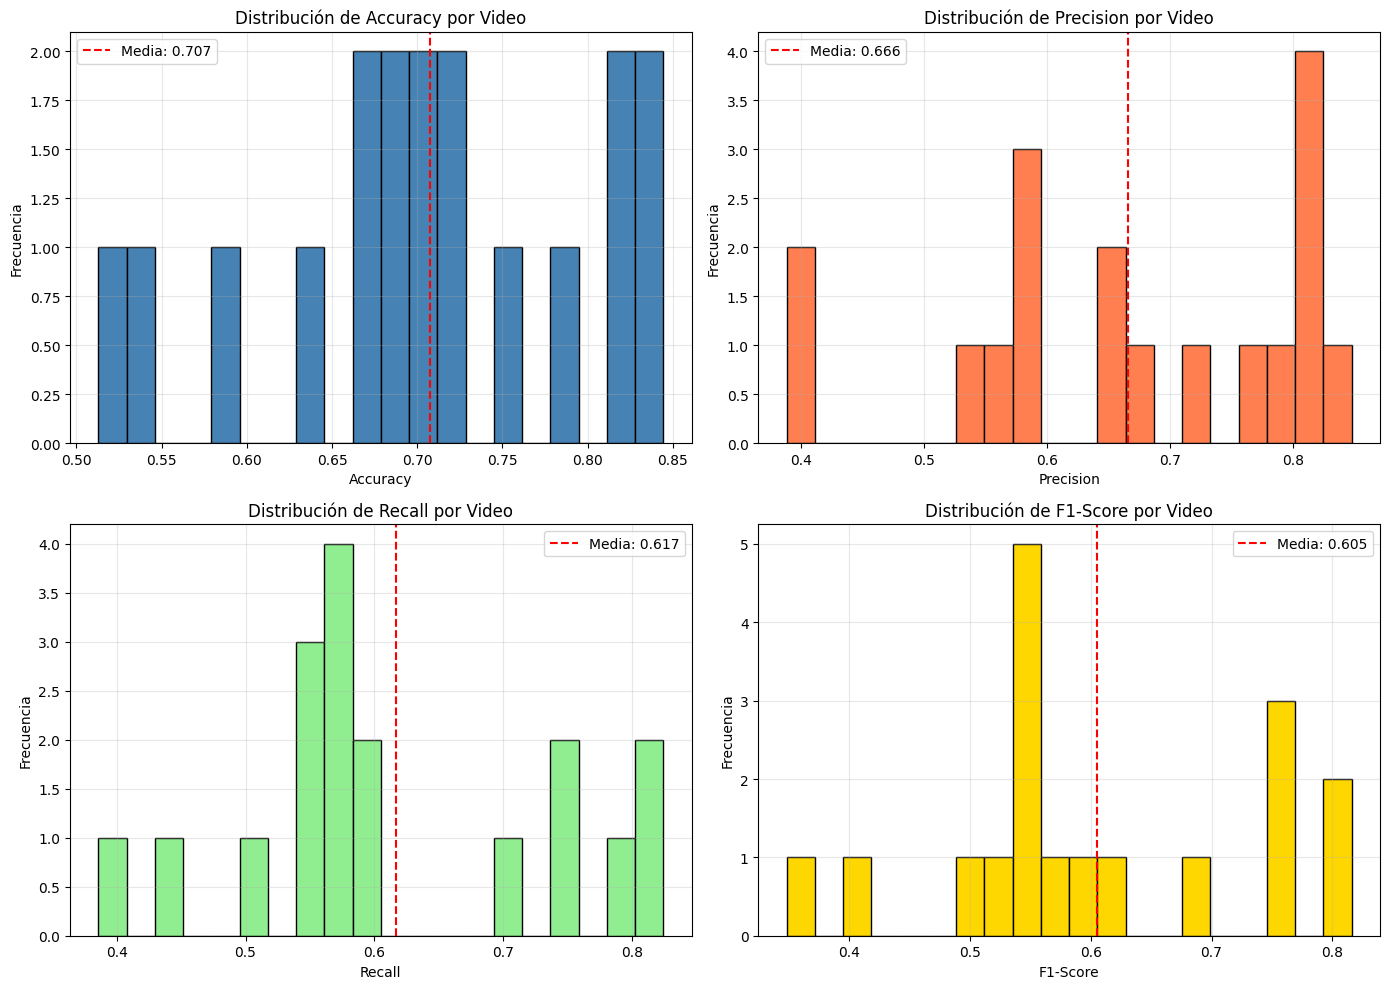

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar detalles de evaluación
df_eval = pd.read_csv('video_evaluation_details.csv')

print("📊 Estadísticas de Métricas por Video:")
print("="*60)
print(df_eval[['accuracy', 'precision', 'recall', 'f1_score']].describe())

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].hist(df_eval['accuracy'], bins=20, color='steelblue', edgecolor='black')
axes[0, 0].axvline(df_eval['accuracy'].mean(), color='red', linestyle='--', label=f"Media: {df_eval['accuracy'].mean():.3f}")
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Accuracy por Video')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Precision
axes[0, 1].hist(df_eval['precision'], bins=20, color='coral', edgecolor='black')
axes[0, 1].axvline(df_eval['precision'].mean(), color='red', linestyle='--', label=f"Media: {df_eval['precision'].mean():.3f}")
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].set_title('Distribución de Precision por Video')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Recall
axes[1, 0].hist(df_eval['recall'], bins=20, color='lightgreen', edgecolor='black')
axes[1, 0].axvline(df_eval['recall'].mean(), color='red', linestyle='--', label=f"Media: {df_eval['recall'].mean():.3f}")
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Recall por Video')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# F1-Score
axes[1, 1].hist(df_eval['f1_score'], bins=20, color='gold', edgecolor='black')
axes[1, 1].axvline(df_eval['f1_score'].mean(), color='red', linestyle='--', label=f"Media: {df_eval['f1_score'].mean():.3f}")
axes[1, 1].set_xlabel('F1-Score')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].set_title('Distribución de F1-Score por Video')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparación por Fuente de Datos


📊 Métricas Promedio por Fuente de Datos:
         accuracy           precision              recall          f1_score  \
             mean       std      mean       std      mean     std      mean   
source                                                                        
Entrega1  0.70724  0.095657  0.666176  0.144367  0.616733  0.1258  0.604985   

                    
               std  
source              
Entrega1  0.132159  


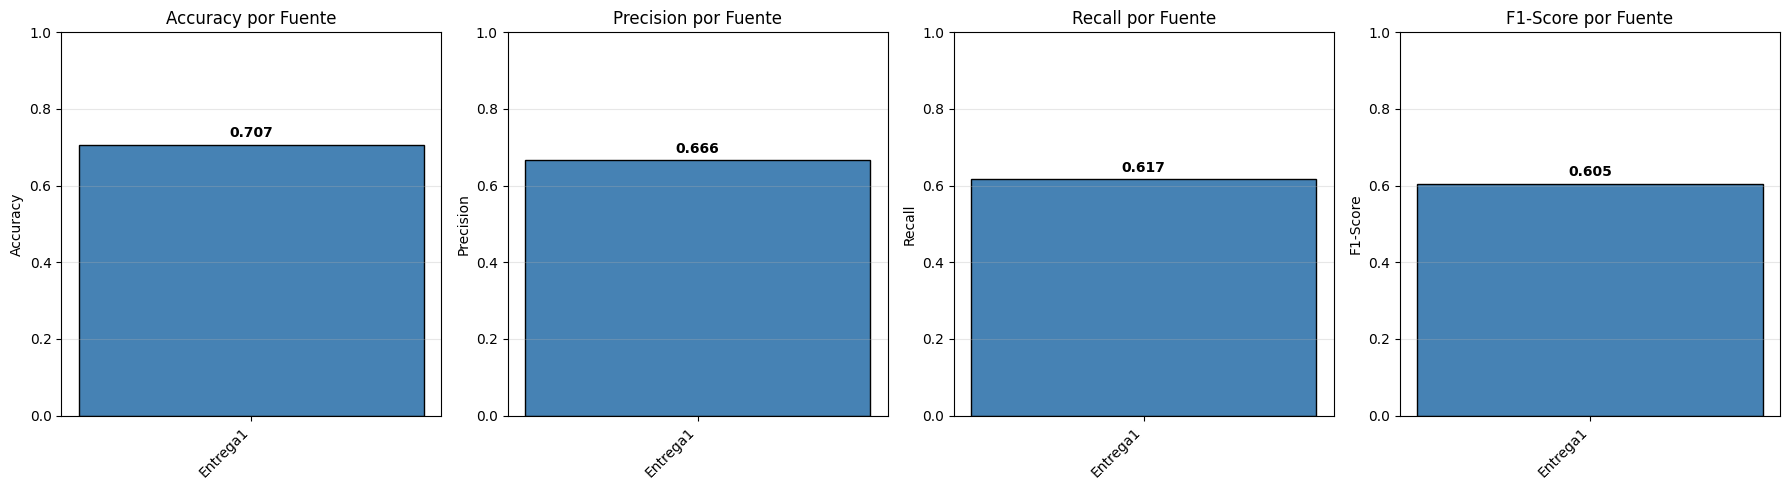

In [7]:
# Comparar métricas por fuente
print("\n📊 Métricas Promedio por Fuente de Datos:")
print("="*60)

grouped = df_eval.groupby('source')[['accuracy', 'precision', 'recall', 'f1_score']].agg(['mean', 'std'])
print(grouped)

# Visualización
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    source_means = df_eval.groupby('source')[metric].mean().sort_values(ascending=False)
    axes[i].bar(range(len(source_means)), source_means.values, color=['steelblue', 'coral', 'lightgreen'][:len(source_means)], edgecolor='black')
    axes[i].set_xticks(range(len(source_means)))
    axes[i].set_xticklabels(source_means.index, rotation=45, ha='right')
    axes[i].set_ylabel(title)
    axes[i].set_title(f'{title} por Fuente')
    axes[i].set_ylim([0, 1])
    axes[i].grid(axis='y', alpha=0.3)
    
    # Agregar valores en las barras
    for j, v in enumerate(source_means.values):
        axes[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Top 10 Mejores y Peores Videos

In [8]:
# Top 10 mejores
print("\n🏆 Top 10 Videos con MEJOR F1-Score:")
print("="*60)
top_10 = df_eval.nlargest(10, 'f1_score')[['video_name', 'source', 'f1_score', 'accuracy', 'samples']]
print(top_10.to_string(index=False))

# Top 10 peores
print("\n⚠️ Top 10 Videos con MENOR F1-Score:")
print("="*60)
bottom_10 = df_eval.nsmallest(10, 'f1_score')[['video_name', 'source', 'f1_score', 'accuracy', 'samples']]
print(bottom_10.to_string(index=False))


🏆 Top 10 Videos con MEJOR F1-Score:
  video_name   source  f1_score  accuracy  samples
Video 14.mp4 Entrega1  0.816121  0.844444      180
Video 16.mp4 Entrega1  0.804619  0.824390      205
 Video 1.mp4 Entrega1  0.759154  0.753086       81
Video 17.mp4 Entrega1  0.757393  0.815642      179
Video 18.mp4 Entrega1  0.754707  0.781250      160
Video 15.mp4 Entrega1  0.676200  0.843575      179
 Video 2.mp4 Entrega1  0.626709  0.673684       95
 Video 4.mp4 Entrega1  0.582467  0.666667       93
 Video 8.mp4 Entrega1  0.570000  0.684932       73
Video 13.mp4 Entrega1  0.554894  0.512821       78

⚠️ Top 10 Videos con MENOR F1-Score:
  video_name   source  f1_score  accuracy  samples
 Video 3.mp4 Entrega1  0.348085  0.545455       66
 Video 7.mp4 Entrega1  0.410937  0.680412       97
 Video 5.mp4 Entrega1  0.492016  0.698925       93
Video 12.mp4 Entrega1  0.533927  0.595588      136
Video 11.mp4 Entrega1  0.548375  0.645455      110
 Video 9.mp4 Entrega1  0.550420  0.726190       84
 Video 

---

## 🎯 Resumen del Pipeline Completo

### Flujo de Trabajo:

```
┌──────────────────────────────────────────────────────────┐
│  PASO 1: Procesamiento de Videos                        │
│  Script: process_all_videos.py                          │
│  Input:  Videos MP4 + JSON de Label Studio              │
│  Output: mediapipe_labels_dataset_combined_enriched.csv │
│  Tiempo: ~10-15 min                                     │
└────────────────────┬─────────────────────────────────────┘
                     │
                     ▼
┌──────────────────────────────────────────────────────────┐
│  PASO 2: Entrenamiento de Modelos                       │
│  Notebook: Entrega 2.ipynb                              │
│  Input:  CSV enriquecido                                │
│  Output: models/*.joblib (RF, XGBoost, SVM, scaler, LE) │
│  Tiempo: ~5-10 min                                      │
└────────────────────┬─────────────────────────────────────┘
                     │
                     ▼
┌──────────────────────────────────────────────────────────┐
│  PASO 3: Evaluación de Métricas                         │
│  Script: evaluate_videos_metrics.py                     │
│  Input:  Videos MP4 + Modelo entrenado                  │
│  Output: video_evaluation_report.txt + CSV              │
│  Tiempo: ~20-30 min                                     │
└──────────────────────────────────────────────────────────┘
```

### Archivos Generados:

| Archivo | Descripción | Tamaño Aprox. |
|---------|-------------|---------------|
| `mediapipe_labels_dataset_combined.csv` | Dataset base con landmarks | ~50 MB |
| `mediapipe_labels_dataset_combined_enriched.csv` | Dataset con features derivadas | ~60 MB |
| `models/best_model.joblib` | Modelo Random Forest óptimo | ~16 MB |
| `models/scaler.joblib` | Normalizador de features | ~2 KB |
| `models/label_encoder.joblib` | Codificador de etiquetas | ~2 KB |
| `video_evaluation_report.txt` | Reporte completo de métricas | ~10 KB |
| `video_evaluation_details.csv` | Métricas por video | ~5 KB |

---

## 📝 Conclusiones

### Ventajas de la Combinación de Clases:

1. **Reducción de confusiones**: Walk forward y Walk backward son muy similares → Walking unificado
2. **Mejor generalización**: Get up y Sit down son transiciones opuestas pero similares → Transition
3. **Modelo más robusto**: Menos clases = menos complejidad = mejor rendimiento
4. **Mayor precisión**: Las clases combinadas son semánticamente coherentes

### Clases Finales (5 en lugar de 7):

| # | Clase | Descripción |
|---|-------|-------------|
| 1 | Standing | De pie estático |
| 2 | Sitting | Sentado |
| 3 | **Walking** | Caminar (adelante o atrás) |
| 4 | **Transition** | Transición (sentarse o levantarse) |
| 5 | Turn | Girar |

### Próximos Pasos:

1. ✅ Analizar métricas globales y por clase
2. ✅ Identificar videos con bajo rendimiento
3. ✅ Comparar fuentes de datos (Entrega 1 vs Entrega 2)
4. 🔄 Ajustar hiperparámetros si es necesario
5. 🚀 Desplegar modelo en aplicación web (Flask)
6. 🎥 Probar inferencia en tiempo real con webcam

---

## ✅ Checklist de Ejecución

- [ ] **Paso 1 ejecutado**: Dataset CSV generado
- [ ] **Paso 2 ejecutado**: Modelos entrenados y guardados
- [ ] **Paso 3 ejecutado**: Métricas calculadas y reportadas
- [ ] **Análisis completado**: Gráficos y comparaciones generadas
- [ ] **Documentación actualizada**: README con instrucciones

---

**¡Proyecto completado con éxito! 🎉**